
# Chapter 12: Spam dataset with ensemble methods - AdaBoost


### Importing the necessary packages

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

np.random.seed(0)

### Plotting functions

In [ ]:
# Some functions to plot our points and draw the lines
def plot_points(features, labels, fix_margins=True):
    X = np.array(features)
    y = np.array(labels)
    spam = X[np.argwhere(y==1)]
    ham = X[np.argwhere(y==0)]
    if fix_margins:
        plt.xlim(0, 11)
        plt.ylim(0, 11)
    plt.scatter([s[0][0] for s in spam],
                [s[0][1] for s in spam],
                s = 100,
                color = 'cyan',
                edgecolor = 'k',
                marker = '^')
    plt.scatter([s[0][0] for s in ham],
                [s[0][1] for s in ham],
                s = 100,
                color = 'red',
                edgecolor = 'k',
                marker = 's')
    plt.xlabel('Lottery')
    plt.ylabel('Sale')
    plt.legend(['Spam','Ham'])

def plot_model(X, y, model, fix_margins=True):
    X = np.array(X)
    y = np.array(y)
    plot_points(X, y)
    plot_step = 0.01
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    if fix_margins:
        x_min=0
        y_min=0
        x_max=12
        y_max=12
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, colors=['red', 'blue'], alpha=0.2, levels=range(-1,2))
    plt.contour(xx, yy, Z,colors = 'k',linewidths = 3)
    plt.show()

def display_tree(dt):
    import sys
    import six
    from IPython.display import Image
    from sklearn.tree import export_graphviz
    import pydotplus
    sys.modules['sklearn.externals.six'] = six

    dot_data = six.StringIO()
    export_graphviz(dt, out_file=dot_data,
                    filled=True, rounded=True,
                    special_characters=True)
    graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
    return Image(graph.create_png())

### Loading dataset - The spam email dataset

In [ ]:
emails = np.array([
    [7,8,1],
    [3,2,0],
    [8,4,1],
    [2,6,0],
    [6,5,1],
    [9,6,1],
    [8,5,0],
    [7,1,0],
    [1,9,1],
    [4,7,0],
    [1,3,0],
    [3,10,1],
    [2,2,1],
    [9,3,0],
    [5,3,0],
    [10,1,0],
    [5,9,1],
    [10,8,1],
])
spam_dataset = pd.DataFrame(data=emails, columns=["Lottery", "Sale", "Spam"])
spam_dataset

,Lottery,Sale,Spam
0,7,8,1
1,3,2,0
2,8,4,1
3,2,6,0
4,6,5,1
5,9,6,1
6,8,5,0
7,7,1,0
8,1,9,1
9,4,7,0


### Defining and plotting our dataset

In [ ]:
features = spam_dataset[['Lottery', 'Sale']]
labels = spam_dataset['Spam']

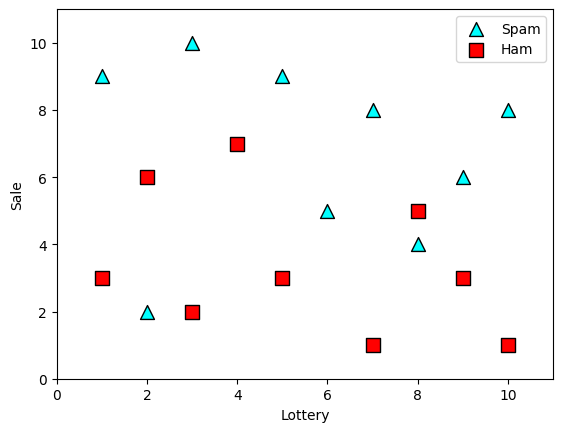

In [ ]:
plot_points(features, labels)

## AdaBoost method

### Traning AdaBoost classifier

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
# Set the random_state so that we always get the same results
adaboost_classifier = AdaBoostClassifier(random_state=0, n_estimators=6)
adaboost_classifier.fit(features, labels)
adaboost_classifier.score(features, labels)

0.7777777777777778

### Plot the model

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


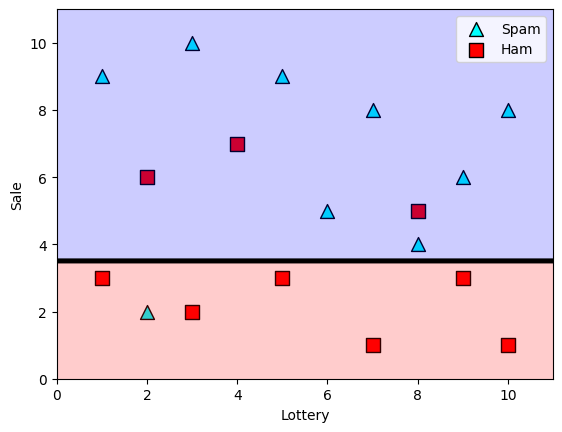

In [ ]:
plot_model(features, labels, adaboost_classifier)

### Plot individual weak learners from AdaBoost model

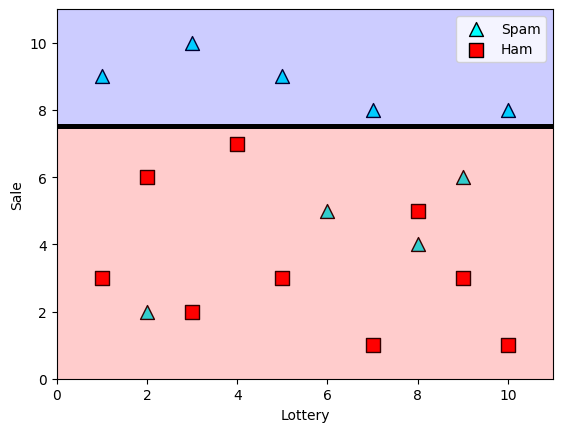

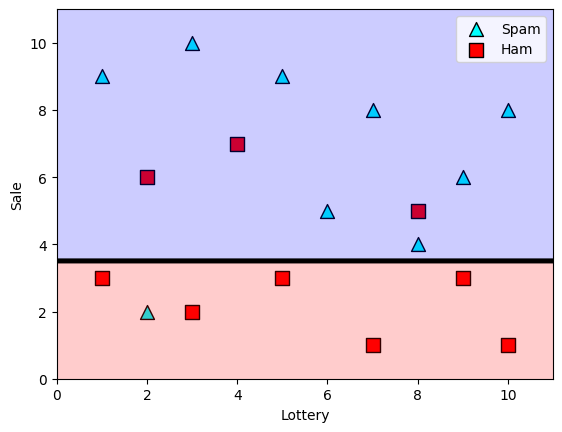

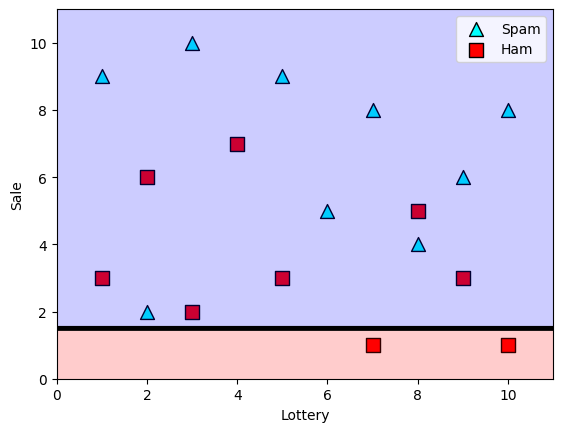

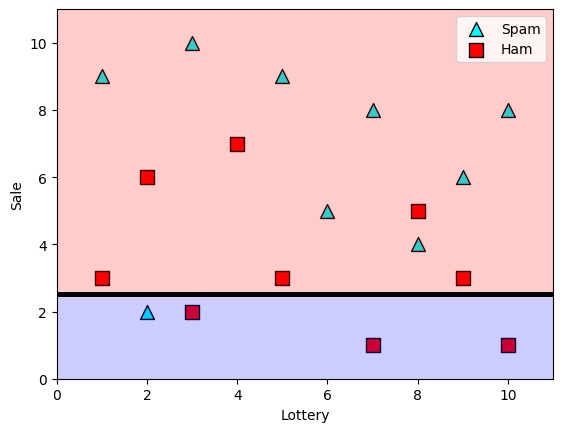

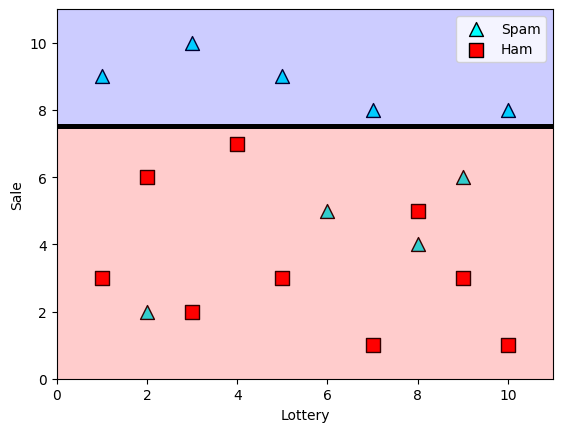

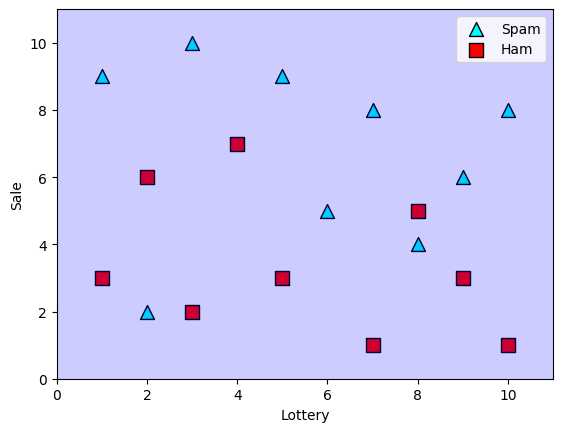

In [ ]:
estimators = adaboost_classifier.estimators_
for estimator in estimators:
    plot_model(features, labels, estimator)
    plt.show()

In [ ]:
adaboost_classifier.estimator_weights_

array([1.25276297, 1.19625076, 0.73639716, 0.67741931, 0.33053568,
       0.44590681])

## Gradient boosting

### Tranin Gradient boosting model

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
gradient_boosting_classifier = GradientBoostingClassifier(random_state=0, n_estimators=5)
gradient_boosting_classifier.fit(features, labels)
gradient_boosting_classifier.score(features, labels)

0.8888888888888888

### Ploting model

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


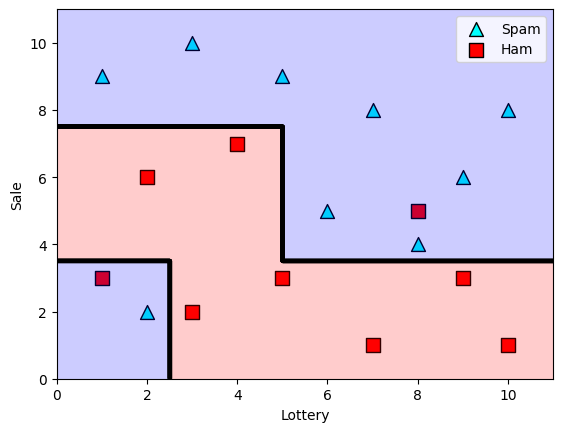

In [ ]:
plot_model(features, labels, gradient_boosting_classifier)

In [ ]:
estimators = gradient_boosting_classifier.estimators_

As an example, let us plot the first of the estimators.

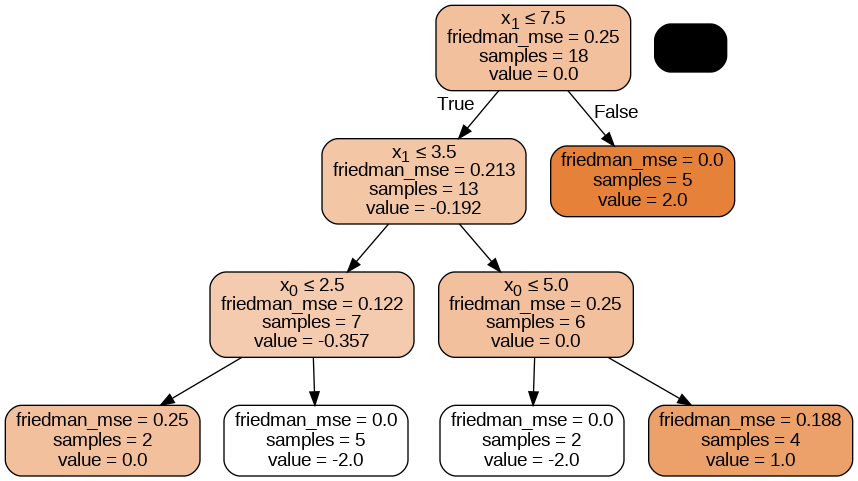

In [ ]:
display_tree(estimators[0][0])

Estimator 1:


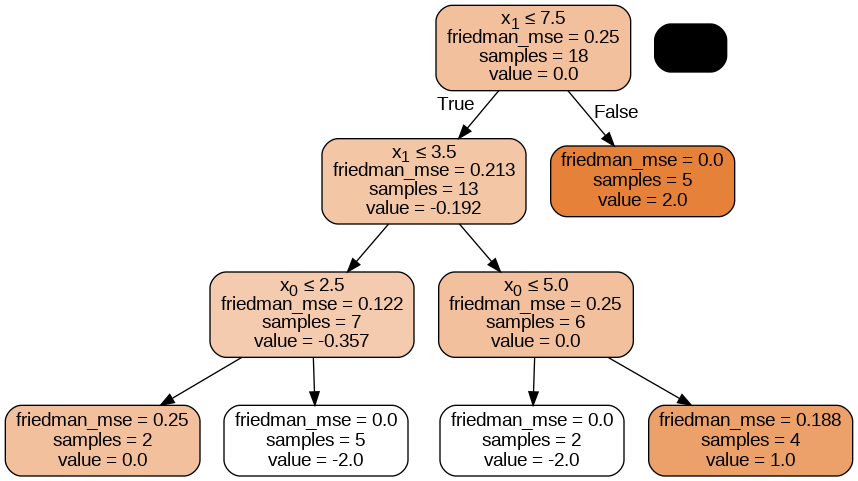

Estimator 2:


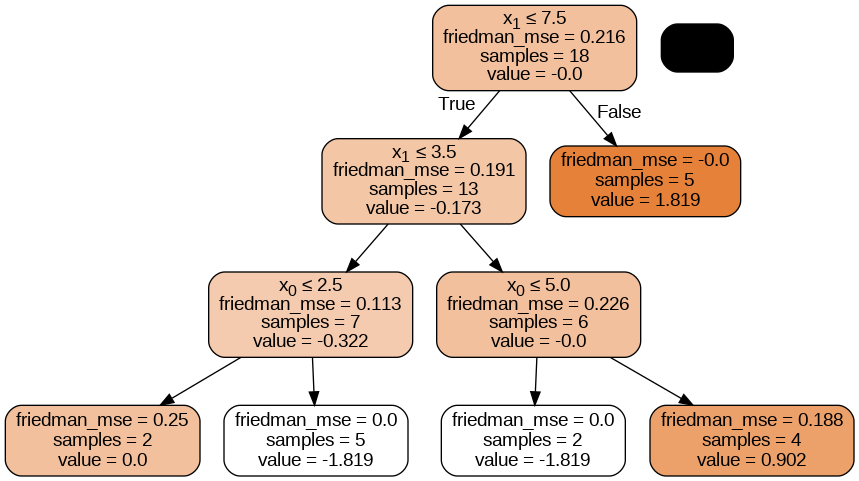

Estimator 3:


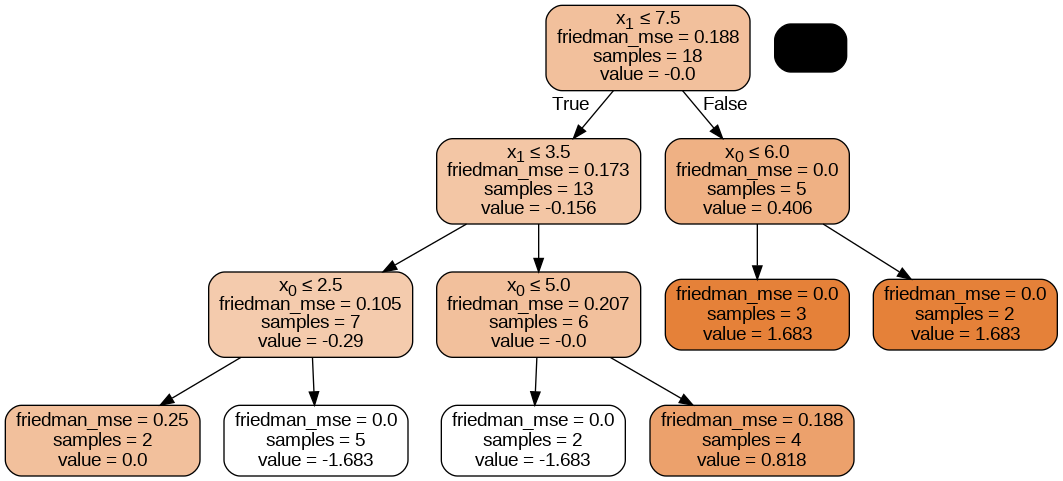

Estimator 4:


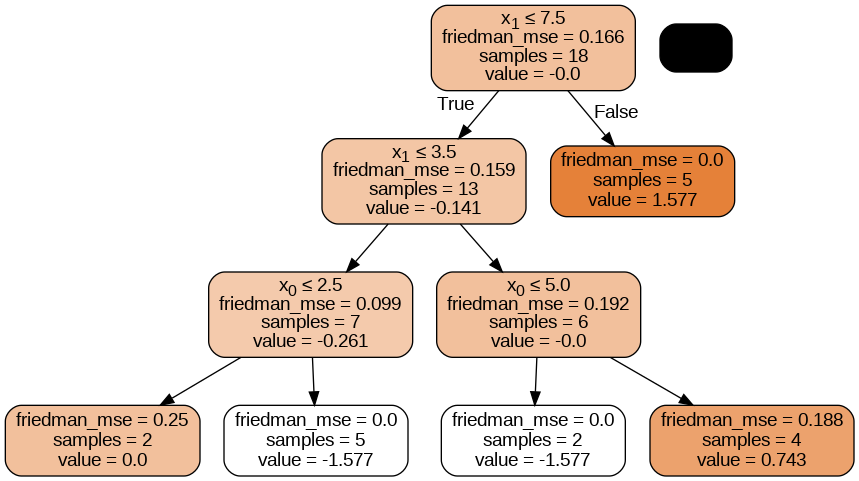

Estimator 5:


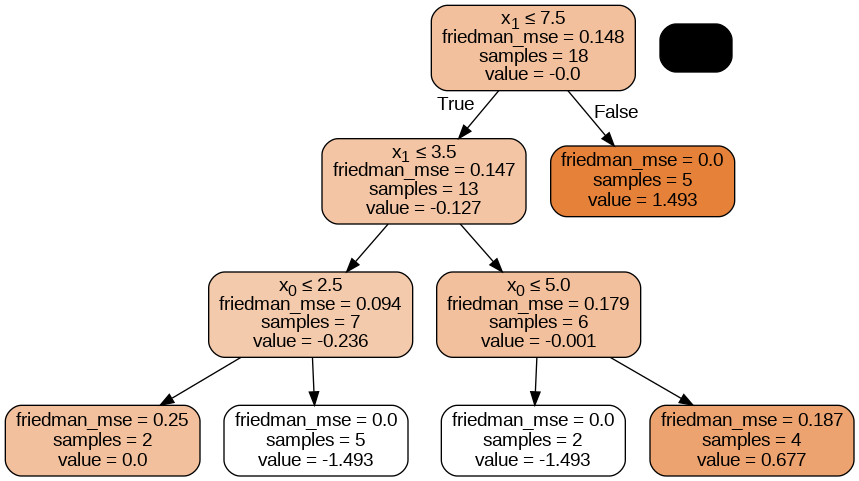

In [ ]:
from IPython.display import display

for i, estimator in enumerate(estimators):
    print(f"Estimator {i+1}:")
    display(display_tree(estimator[0]))

## XGBoost

### Tranin XGBoost model

In [ ]:
import xgboost
from xgboost import XGBClassifier
xgboost_classifier = XGBClassifier(random_state=0, n_estimators=5)
xgboost_classifier.fit(np.array(features), labels)
xgboost_classifier.score(np.array(features), labels)

0.8888888888888888

### Ploting model

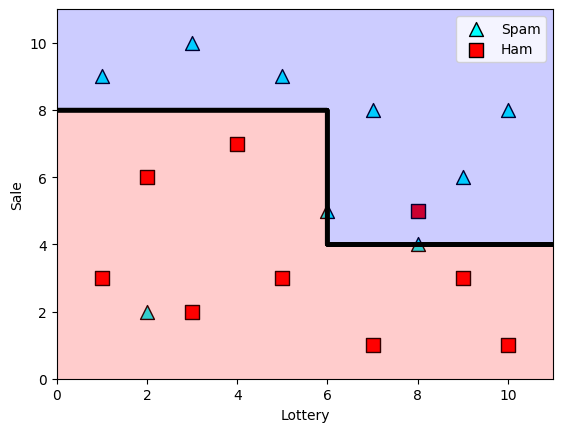

In [ ]:
plot_model(features, labels, xgboost_classifier)

Estimator 1:


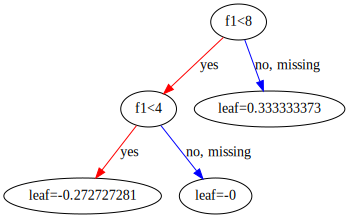

Estimator 2:


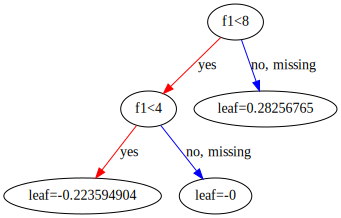

Estimator 3:


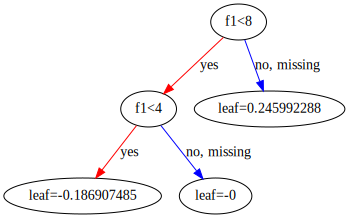

Estimator 4:


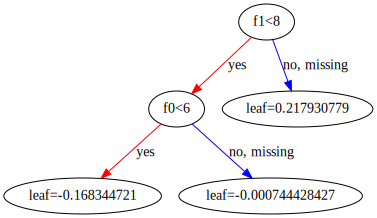

Estimator 5:


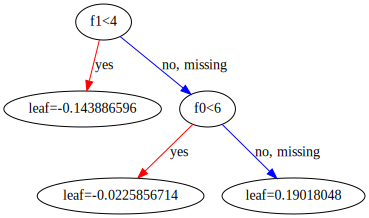

In [ ]:
from xgboost import to_graphviz
from IPython.display import display

for i in range(xgboost_classifier.n_estimators):
    print(f"Estimator {i+1}:")
    display(to_graphviz(xgboost_classifier, tree_idx=i))